# Thursday March 12th 2026
## Announcements
- Midterm 2 tonight March 12, 7:00 - 9:00 PM in KTH/B135.

## Some review
- Any favourite questions from the assignments/ practice test/ elsewhere?

## Review 1 - List Comprehension

### Fizz-Buzz

Make a list of the integers $1$ through $100$ with the following rules:
1. If $n$ is not divisible by $3$ or $5$ then simply put $n$ in the list.
2. If $n$ is divisible by $3$ then write `Fizz` in place of $n$.
3. If $n$ is divisible by $5$ then write `Buzz` in place of $n$. 
4. If $n$ is divisible by $3$ and by $5$ write `FizzBuzz` in place of $n$.

In [68]:
# CODE HERE
L = []
for n in range(1,101):
    if n%3==0 and n%5==0:
        L.append('FizzBuzz')
    elif n%3==0:
        L.append('Fizz')
    elif n%5==0:
        L.append('Buzz')
    else:
        L.append(n)
print(L)

[1, 2, 'Fizz', 4, 'Buzz', 'Fizz', 7, 8, 'Fizz', 'Buzz', 11, 'Fizz', 13, 14, 'FizzBuzz', 16, 17, 'Fizz', 19, 'Buzz', 'Fizz', 22, 23, 'Fizz', 'Buzz', 26, 'Fizz', 28, 29, 'FizzBuzz', 31, 32, 'Fizz', 34, 'Buzz', 'Fizz', 37, 38, 'Fizz', 'Buzz', 41, 'Fizz', 43, 44, 'FizzBuzz', 46, 47, 'Fizz', 49, 'Buzz', 'Fizz', 52, 53, 'Fizz', 'Buzz', 56, 'Fizz', 58, 59, 'FizzBuzz', 61, 62, 'Fizz', 64, 'Buzz', 'Fizz', 67, 68, 'Fizz', 'Buzz', 71, 'Fizz', 73, 74, 'FizzBuzz', 76, 77, 'Fizz', 79, 'Buzz', 'Fizz', 82, 83, 'Fizz', 'Buzz', 86, 'Fizz', 88, 89, 'FizzBuzz', 91, 92, 'Fizz', 94, 'Buzz', 'Fizz', 97, 98, 'Fizz', 'Buzz']


In [ ]:
'Fizz'*(n%3==0)+'Buzz'*(n%5==0)

In [ ]:
L = ['Fizz'*(n%3==0)+'Buzz'*(n%5==0) or n for n in range(1,101)]

In [ ]:
L = ['Fizz'*(n%3==0)+'Buzz'*(n%5==0) 
     if ((n%3==0) or (n%5==0)) else n for n in range(1,101)]

In [69]:
import numpy as np

## Review 2 - Numpy arrays

Write a function $g(A,B)$ which takes as input two numpy arrays $A$ and $B$ (of identical but arbitrary shape) and returns a third **new** Numpy array of the same shape as $A$ and $B$ with values given by the following rules:
- If $A[i] > B[i]$, then $C[i] = A[i]+B[i]$.
- Else, $C[i] = B[i] - A[i]$

For example, if `A = [1. -2. 3.]` and `B = [1. 3. -2.]`, then `g(A,B) = [0. 5. 1.]`

In [70]:
def g(A : np.array, B : np.array) -> np.array:
    C = np.empty(A.shape)
    for idx,_ in np.ndenumerate(A):
        if  A[idx] > B[idx]:
            C[idx] = A[idx] + B[idx]
        else:
            C[idx] = B[idx] - A[idx]

    return C

In [ ]:
def g2(A, B) :
    C = np.empty(A.shape)
    C[A>B] = A[A>B] + B[A>B]
    C[A<=B] = B[A<=B] - A[A<=B]
    return C


In [71]:
A = np.array([1.,-2.,3.])
B = np.array([1.,3.,-2.])
print(g(A,B))

[0. 5. 1.]


### Key points
- The function created should work regardless of the size/shape of $A$ and $B$.
- The function should leverage Numpy vectorization.

## Review 3 - *args

Write a function which takes in an arbitrary number of numpy arrays and computes their sum.

In [72]:
def sum_arrays(*Arr):
    sum = np.zeros(Arr[0].shape)
    for A in Arr:
        sum+=A
    return sum
    

In [73]:
A = np.array([[1,2,3],[4,5,6]])
B = np.array([[-1,-2,-3],[-4,-5,-6]])
C = np.array([[1,0,0],[0,1,0]])
print(sum_arrays(A,B,C))

[[1. 0. 0.]
 [0. 1. 0.]]


In [74]:
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np

grades = np.loadtxt('grades.csv', skiprows = (1), usecols = (3, 4, 5, 6, 7, 8, 9), delimiter = ',')
print(grades)


[[96. 77. 82. ... 88. 78. 91.]
 [94. 76. 87. ... 90. 67. 88.]
 [92. 79. 85. ... 76. 60. 87.]
 ...
 [91. 73. 84. ... 96. 75. 83.]
 [92. 78. 79. ... 90. 65. 90.]
 [94. 65. 86. ... 83. 74. 85.]]


Let's plot an histogram of the final grades

Text(0.5, 1.0, 'Final grades')

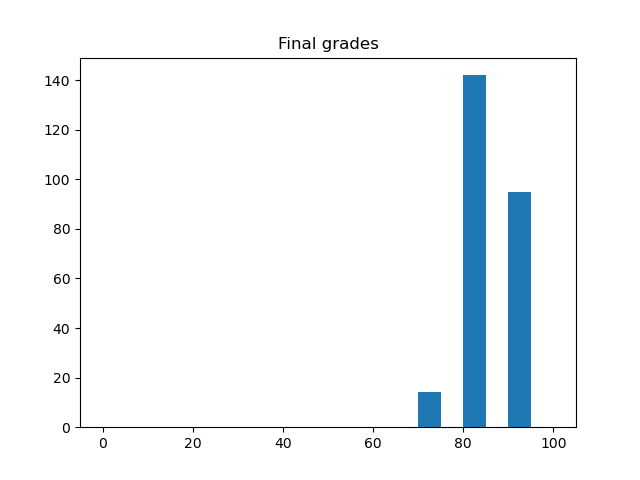

In [75]:
plt.close('all')
fig, ax = plt.subplots()
ax.hist(grades[:,4], bins = 10, range = (0,100),width = 5)
ax.set_title("Final grades")
# ax.axis([0,11,0,20])


### Exercise

Suppose that your course had two grading schemes. They have been computed already in the numpy arras `f1` and `f2`. Make a new array called `f` which takes the best of the two final grades for each student.

In [ ]:
f1 = np.random.uniform(low = 0, high = 100, size = (250,))
f2 = np.random.normal(loc = 75.0, scale = 15.0, size = (250,))

def best(f1,f2):
    f = np.max(f1.shape)
    f[f1>f2] = f1[f1>f2]
    f[f1<=f2] = f2[f1<=f2]
    return f


print(best(f1,f2))
print(np.mean(best(f1,f2)))

[ 93.63860916  83.1544007   71.43087352  73.30995643  90.63550436
  83.73224706  59.74255139  74.13199231  79.36888038  60.89701423
  80.53499796  74.38080094  49.76979509  51.0695021   88.72075694
  70.70529767  81.00501971  74.69013535  97.41942084  94.98136553
  49.11722175  76.62606508  75.70396551  79.18257566  74.44659838
  77.85138677  95.0396967   67.76869544  84.09819357  65.69029914
  65.40998805  80.46450002  81.21800753  96.31646917 109.53823319
  81.71729542  76.38464349  96.32659042  79.76584167  80.04470859
  88.17732503  95.76758925  80.15152572  91.68328619  85.48315804
  56.73577557  57.1128596   83.62450166  86.93521986  39.69687882
  88.88037388  77.57961651  72.98683001  65.93647285  65.51782304
  73.7579475   54.43637719  78.01562941  60.82169963  76.56790876
  77.39645894  61.1701069   50.86370433 100.42310359  69.55642267
  91.13866285  80.34927236  53.65565023  70.67795673  98.68985074
  73.59509539  70.89862691  64.78365549  61.03716138 103.15449098
  92.33886

## Parametric curves

Imagine a particle moving in the plane, and let $(x(t), y(t))$ be its position at any given $t$. The trajectory of the particle in an interval of time $t_1, t_2)$ is a *parametric curve* defined by $(x(t), y(t))$, and $(t_1, t_2)$.

For instance, the parametric curve described by $(\cos(t), \sin(t))$ for $t \in (0, 2\pi)$ is the unit circle with counterclockwise orientation


In [ ]:
plt.close('all')
fig, ax = plt.subplots()
T = np.linspace(0,2*np.pi, 101)
ax.plot(np.cos(T), np.sin(T))
ax.grid()
ax.set_aspect('equal')

## Composing circular motions

In [ ]:
plt.close('all')
fig, ax = plt.subplots()
ax.set_aspect('equal')
def x1(t):
    return 2 * np.cos(t) 
def y1(t):
    return 2 * np.sin(t) 
def x2(t):
    return 0.5 * np.cos(10*t) 
def y2(t):
    return 0.5 * np.sin(10*t) 
T = np.linspace(0, 2*np.pi, 501)
ax.plot(x1(T), y1(T), color = 'red')
ax.plot(x1(T)+ x2(T), y1(T)+y2(T), color = 'blue')

## Lissajou curves
Lissajou curves are parametric curves of defined by
$$
    x(t) = A \cos(at),\ y(t) = B\sin(bt + \varphi).
$$


In [ ]:
def x(t, A = 1, a = 1):
    return A * np.cos(a * t)
def y(t, B = 1, b = 1, phi = 0):
    return B * np.sin(b * t + phi)

plt.close('all')
fig, ax = plt.subplots()
ax.set_aspect('equal')

T = np.linspace(0, 2*np.pi, 501)
A = 1
B = 1
a = 1
b = 1
phi = np.pi/2
for phi in np.linspace(0, np.pi/2, 5):
    plt.plot((lambda t : x(t, A, a))(T), (lambda t : y(t, B, b, phi))(T), label = f'φ={phi / np.pi}π')
    ax.legend()

In [ ]:
plt.close('all')
fig, ax = plt.subplots()
ax.set_aspect('equal')

T = np.linspace(0, 4*np.pi, 501)
A = 2
B = 1
a = 1
b = 1
phi = 0
for a in np.linspace(1, 2, 3):
    plt.plot((lambda t : x(t, A, a))(T), (lambda t : y(t, B, b, phi))(T), label = f'a/b = {a/b}')
    ax.legend()

In [ ]:
plt.close('all')
fig, ax = plt.subplots()
ax.set_aspect('equal')

T = np.linspace(0, 2*np.pi, 501)
A = 2
B = 1
a = 2
b = 1
phi = np.pi/2
for phi in np.linspace(0, np.pi/2, 5):
    plt.plot((lambda t : x(t, A, a))(T), (lambda t : y(t, B, b, phi))(T), label = f'φ={phi / np.pi}π')
    ax.legend()

## 3D plots
Matplotlib has limited 3d plotting abilities. We'll see at teh end of the class how to do nicer 3d plots.

Imagine a particle moving in space, and let $(x(t), y(t), z(t))$ be its position at any given $t$. The trajectory of the particle is a curve in 3d space described by  the functions $(x(t), y(t), z(t))$. Let's try to visualize it


In [ ]:
plt.close('all')

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

def x(t):
    return np.cos(t)
def y(t):
    return np.sin(t)
def z(t):
    return t / 4. / np.pi

T = np.linspace(0,4*np.pi, 101)
ax.plot(x(T), y(T), z(T), label='parametric curve')
ax.legend()

## 3D surfaces

In the plane, the set of points $(x,y)$ such that $y = f(x)$ is the graph of the function $f$.

A *function of two variables*, $x, y$ is a rule which to an ordered pair $(x,y)$ in a domain associates a value $f(x,y)$. The domain of such a function is a region of the plane. The set of all points $(x,y,z)$ such that $f(x,y) = z$ is a *surface* which we call the graph of $f$.

For instance take $f(x,y) = 2x+3y$. The graph of $f$ is the set of all points in space such that $2x+3y = z$, $i.e.$ the plane of equation $2x+3y-z = 0$. Let's plot a few functions of two variables.

In [ ]:
def f(x,y):
    return 2*x+3*y

x = np.linspace(-1,1,5)
y = np.linspace(-1,1,5)
X, Y = np.meshgrid(x, y)
print(X)
print(Y)

In [ ]:
x = np.linspace(-1,1,101)
y = np.linspace(-1,1,101)
X, Y = np.meshgrid(x, y)
fig = plt.figure() 
ax =fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,f(X,Y),edgecolor='royalblue', lw=0.5, rstride=10, cstride=10, alpha=0.3)

### Something more interesting

In [ ]:
def g(x,y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)
fig = plt.figure() 
ax =fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,g(X,Y),edgecolor='royalblue', lw=0.5, rstride=10, cstride=10, alpha=0.3)